In [0]:
# ============================================================
# CELDA 1: Capa Bronze — En Memoria (Solución DBFS_DISABLED)
# ============================================================
import numpy as np
import pandas as pd
from pyspark.sql import functions as F

np.random.seed(42)
n = 2000
distritos = ["Miraflores", "San Isidro", "SJL", "Comas", "Villa El Salvador", "Los Olivos", "Surco", "Ate", "Callao", "Independencia"]
tipos = ["persona_a_persona", "persona_a_comercio", "retiro_bcp", "recarga"]
estados = ["completada", "completada", "completada", "rechazada", "pendiente"]

data = {
    "id_transaccion": [f"YP{i:07d}" for i in range(1, n + 1)],
    "fecha":           pd.date_range("2025-01-01", periods=n, freq="1h").strftime("%Y-%m-%d").tolist(),
    "hora":            [f"{h:02d}:{m:02d}" for h, m in zip(np.random.randint(0, 24, n), np.random.randint(0, 60, n))],
    "monto_soles":     np.round(np.random.exponential(45, n), 2).tolist(),
    "tipo":            np.random.choice(tipos, n).tolist(),
    "distrito_origen": np.random.choice(distritos, n).tolist(),
    "estado":          np.random.choice(estados, n, p=[0.75, 0.1, 0.05, 0.07, 0.03]).tolist(),
    "id_usuario":      [f"USR{np.random.randint(1000, 9999)}" for _ in range(n)],
    "es_comercio":     np.random.choice([True, False], n, p=[0.4, 0.6]).tolist()
}

df_pandas = pd.DataFrame(data)

# Creamos el DataFrame de Spark global para que la Celda 2 lo pueda ver
df_bronze_global = spark.createDataFrame(df_pandas)

# Lo registramos como una vista temporal en memoria de Spark SQL
df_bronze_global.createOrReplaceTempView("v_bronze")

print(f"✅ Capa Bronze cargada en memoria: {df_bronze_global.count()} filas")
df_bronze_global.show(5)

✅ Capa Bronze cargada en memoria: 2000 filas
+--------------+----------+-----+-----------+------------------+---------------+----------+----------+-----------+
|id_transaccion|     fecha| hora|monto_soles|              tipo|distrito_origen|    estado|id_usuario|es_comercio|
+--------------+----------+-----+-----------+------------------+---------------+----------+----------+-----------+
|     YP0000001|2025-01-01|06:25|      35.47| persona_a_persona|          Surco|completada|   USR9055|      false|
|     YP0000002|2025-01-01|19:07|       4.16|persona_a_comercio|          Surco|completada|   USR4216|       true|
|     YP0000003|2025-01-01|14:35|      42.01|        retiro_bcp|     San Isidro|completada|   USR6688|      false|
|     YP0000004|2025-01-01|10:47|        7.4|        retiro_bcp|     Los Olivos|completada|   USR5364|      false|
|     YP0000005|2025-01-01|07:29|       1.41|           recarga|     San Isidro|completada|   USR7042|      false|
+--------------+----------+-----+--

In [0]:
# ============================================================
# CELDA 2: Capa Silver — Transformación desde Memoria
# ============================================================
# En lugar de leer un archivo Parquet bloqueado, leemos la vista de la RAM
df_bronze_input = spark.table("v_bronze")

# Resolvemos los espacios vacíos del examen parcial
df_silver = df_bronze_input \
    .filter(F.col("estado") == "completada") \
    .withColumn("monto_pesos", F.round(F.col("monto_soles") * 1050, 2)) \
    .drop("es_comercio")

# Guardamos el resultado en una nueva vista temporal en memoria
df_silver.createOrReplaceTempView("v_silver")

print(f"✅ Capa Silver completada en memoria: {df_silver.count()} filas filtradas")
df_silver.show(5)

✅ Capa Silver completada en memoria: 1802 filas filtradas
+--------------+----------+-----+-----------+------------------+---------------+----------+----------+-----------+
|id_transaccion|     fecha| hora|monto_soles|              tipo|distrito_origen|    estado|id_usuario|monto_pesos|
+--------------+----------+-----+-----------+------------------+---------------+----------+----------+-----------+
|     YP0000001|2025-01-01|06:25|      35.47| persona_a_persona|          Surco|completada|   USR9055|    37243.5|
|     YP0000002|2025-01-01|19:07|       4.16|persona_a_comercio|          Surco|completada|   USR4216|     4368.0|
|     YP0000003|2025-01-01|14:35|      42.01|        retiro_bcp|     San Isidro|completada|   USR6688|    44110.5|
|     YP0000004|2025-01-01|10:47|        7.4|        retiro_bcp|     Los Olivos|completada|   USR5364|     7770.0|
|     YP0000005|2025-01-01|07:29|       1.41|           recarga|     San Isidro|completada|   USR7042|     1480.5|
+--------------+------

In [0]:
# ============================================================
# CELDA 3: Gold — Agregaciones para el Dashboard Ejecutivo
# ============================================================
df_silver_input = spark.table("v_silver")

# Agrupamos y calculamos las sumas por distrito
df_gold = df_silver_input \
    .groupBy("distrito_origen") \
    .agg(
        F.count("id_transaccion").alias("total_transacciones"),
        F.sum("monto_soles").alias("monto_total_soles")
    ) \
    .orderBy(F.col("monto_total_soles").desc())

# Lo guardamos en memoria para que la Celda 4 lo pueda graficar
df_gold.createOrReplaceTempView("v_gold")

print("✅ Capa Gold calculada con éxito. Lista para graficar.")

✅ Capa Gold calculada con éxito. Lista para graficar.


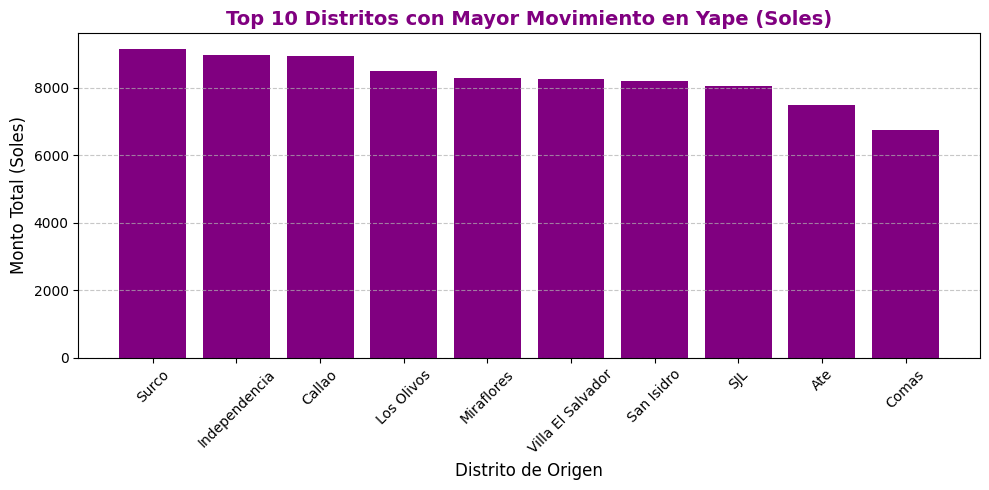

In [0]:
# ============================================================
# CELDA 4: Visualización — Gráfico de barras con Matplotlib
# ============================================================
import matplotlib.pyplot as plt

# 1. Pasamos el Top 10 de Spark a Pandas para poder graficarlo fácilmente
df_grafico = spark.table("v_gold").limit(10).toPandas()

# 2. Creamos la figura del gráfico
plt.figure(figsize=(10, 5))
plt.bar(df_grafico["distrito_origen"], df_grafico["monto_total_soles"], color="purple")

# 3. Personalizamos el diseño con los colores de Yape
plt.title("Top 10 Distritos con Mayor Movimiento en Yape (Soles)", fontsize=14, fontweight="bold", color="purple")
plt.xlabel("Distrito de Origen", fontsize=12)
plt.ylabel("Monto Total (Soles)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# 4. Mostramos el gráfico en pantalla
plt.tight_layout()
plt.show()